<a href="https://colab.research.google.com/github/AbiFani/Challenge_TelecomX_parte2/blob/main/Challenge_TelecomX__parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge TelecomX parte 2: Predicción de Cancelación (Churn)

El Desafío Telecom X parte 2 ofrece una oportunidad única para aplicar conocimientos fundamentales de **estadística, regresión lineal y machine learning**, además de habilidades esenciales en ciencia de datos, en un escenario empresarial real.

# 🛠️ Preparación de los Datos

## Extraccion del archivo tratado

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [73]:
# importar liberias
import pandas as pd

In [74]:
# leer archivo y guardar en un dataframe
datos = pd.read_csv("/content/datos_tratados2.csv")

# mostrar primeras 5 filas
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


## Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [75]:
# eliminar columna 'customerID'
datos = datos.drop('customerID', axis=1)

# mostrar primeras 5 filas
datos.head(5)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [76]:
# conocer las ultimas filas
datos.tail(5)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
7262,0,Female,0,0,0,13,1,0,DSL,1,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7263,1,Male,0,1,0,22,1,1,Fiber optic,0,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,0,Male,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,0,Male,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667
7266,0,Male,0,1,1,63,0,0,DSL,1,...,1,0,1,1,Two year,0,Electronic check,59.00,3707.60,1.966667


In [77]:
# imprimir dataframe filas y columnas
datos.shape

(7267, 21)

In [78]:
# conocer los metadatos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   int64  
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   int64  


## Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [79]:
# conocer descripcion
datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [80]:
# conocer variables categoricas
datos.describe(include='O')

,gender,InternetService,Contract,PaymentMethod
count,7267,7267,7267,7267
unique,2,3,3,4
top,Male,Fiber optic,Month-to-month,Electronic check
freq,3675,3198,4005,2445


In [81]:
# Crear un dataset de ejemplo
#datos = pd.DataFrame({'gender': ['Female', 'Male']})

# Aplicar One-Hot Encoding
#datos = pd.get_dummies(datos, columns=['gender'])
#datos


In [82]:
# modificar tipo de datos con 3 categorias
datos['gender'] = datos['gender'].replace({'Female':0,'Male':1})
datos['InternetService'] = datos['InternetService'].replace({'DSL':1,'Fiber optic':1,'No':0})
datos['Contract'] = datos['Contract'].replace({'Month-to-month':1,'One year':1,'Two year':1})
datos['PaymentMethod'] = datos['PaymentMethod'].replace({'Electronic check':1,'Mailed check':1,'Bank transfer (automatic)':1,'Credit card (automatic)':1})
#mostrar 3 muestras
datos.head(3)

/tmp/ipykernel_166/2588004616.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['gender'] = datos['gender'].replace({'Female':0,'Male':1})
/tmp/ipykernel_166/2588004616.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['InternetService'] = datos['InternetService'].replace({'DSL':1,'Fiber optic':1,'No':0})
/tmp/ipykernel_166/2588004616.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,0,0,1,1,9,1,0,1,0,...,0,1,1,0,1,1,1,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,1,1,0,...,0,0,0,1,1,0,1,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,0,1,0,...,1,0,0,0,1,1,1,73.9,280.85,2.463333


In [83]:
# crear variables categoricas
categoricas = ['gender','InternetService','Contract','PaymentMethod']

# codificar variables con 0, 1
pd.get_dummies(data= datos,columns=categoricas,dtype=int).head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_0,gender_1,InternetService_0,InternetService_1,Contract_1,PaymentMethod_1
0,0,0,1,1,9,1,0,0,1,0,...,1,65.6,593.30,2.186667,1,0,0,1,1,1
1,0,0,0,0,9,1,1,0,0,0,...,0,59.9,542.40,1.996667,0,1,0,1,1,1
2,1,0,0,0,4,1,0,0,0,1,...,1,73.9,280.85,2.463333,0,1,0,1,1,1
3,1,1,1,0,13,1,0,0,1,1,...,1,98.0,1237.85,3.266667,0,1,0,1,1,1
4,1,1,1,0,3,1,0,0,0,0,...,1,83.9,267.40,2.796667,1,0,0,1,1,1


In [84]:
# crear variable datos codificados y almacenar dummies
datos_codificados = pd.get_dummies(data= datos,columns=categoricas,dtype=int)

# mostrar 5 muestras
datos_codificados.sample(15)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_0,gender_1,InternetService_0,InternetService_1,Contract_1,PaymentMethod_1
4862,0,0,0,0,1,1,0,0,0,0,...,1,43.85,43.85,1.461667,0,1,0,1,1,1
4992,0,0,1,0,54,1,1,1,1,1,...,0,109.55,6118.95,3.651667,0,1,0,1,1,1
4745,1,0,0,0,1,1,0,0,0,0,...,1,69.60,69.60,2.320000,0,1,0,1,1,1
3344,1,0,1,0,16,1,1,0,0,0,...,1,73.85,1284.20,2.461667,0,1,0,1,1,1
2561,1,0,0,0,65,1,1,0,1,1,...,1,109.15,6941.20,3.638333,0,1,0,1,1,1
5223,0,0,0,0,17,1,1,0,0,1,...,0,80.05,1345.65,2.668333,1,0,0,1,1,1
2996,0,0,0,0,63,1,1,0,1,0,...,0,97.45,6253.00,3.248333,1,0,0,1,1,1
3029,0,0,0,1,28,1,0,0,0,0,...,0,20.25,535.35,0.675000,1,0,1,0,1,1
2509,0,0,0,0,35,1,1,0,0,0,...,0,26.20,954.90,0.873333,0,1,1,0,1,1
1207,1,0,0,1,1,1,0,0,0,0,...,1,19.45,19.45,0.648333,0,1,1,0,1,1


In [85]:
# mostrar tipos de dato
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Churn              7267 non-null   int64  
 1   SeniorCitizen      7267 non-null   int64  
 2   Partner            7267 non-null   int64  
 3   Dependents         7267 non-null   int64  
 4   tenure             7267 non-null   int64  
 5   PhoneService       7267 non-null   int64  
 6   MultipleLines      7267 non-null   int64  
 7   OnlineSecurity     7267 non-null   int64  
 8   OnlineBackup       7267 non-null   int64  
 9   DeviceProtection   7267 non-null   int64  
 10  TechSupport        7267 non-null   int64  
 11  StreamingTV        7267 non-null   int64  
 12  StreamingMovies    7267 non-null   int64  
 13  PaperlessBilling   7267 non-null   int64  
 14  Charges.Monthly    7267 non-null   float64
 15  Charges.Total      7256 non-null   float64
 16  Cuentas_Diarias    7267 

## Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

In [86]:
# contar clientes que cancelaron o estan activos, Cancelación (0 = No, 1 = Sí)
datos["Churn"].value_counts()

,count
Churn,
0,5398
1,1869


In [87]:
# mostrar en porcentaje la cantidad de clientes
datos["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.74281
1,0.25719


## Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

## Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

# 🎯 Correlación y Selección de Variables

## Análisis de Correlación

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [88]:
# correlacion entre los clientes cancelaron y los que permanencieron
datos.corr(numeric_only=True)['Churn'].sort_values(ascending=False)


,Churn
Churn,1.000000
InternetService,0.224051
Cuentas_Diarias,0.189866
Charges.Monthly,0.189866
PaperlessBilling,0.186666
SeniorCitizen,0.146733
StreamingTV,0.062430
StreamingMovies,0.060586
MultipleLines,0.039343
PhoneService,0.012571


In [89]:
# crear matriz de correlacionn
datos.corr(numeric_only=True)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
Churn,1.000000,-0.009555,0.146733,-0.148546,-0.161384,-0.344079,0.012571,0.039343,0.224051,-0.166828,...,-0.063452,-0.160440,0.062430,0.060586,NaN,0.186666,NaN,0.189866,-0.194440,0.189866
gender,-0.009555,1.000000,-0.004288,-0.005007,0.012038,0.005765,-0.005073,-0.007805,-0.006318,-0.016974,...,-0.002740,-0.009112,-0.008451,-0.012475,NaN,-0.011273,NaN,-0.013889,0.000488,-0.013889
SeniorCitizen,0.146733,-0.004288,1.000000,0.022970,-0.212952,0.018187,0.010060,0.144567,0.182697,-0.037953,...,0.060358,-0.059376,0.103655,0.119374,NaN,0.157734,NaN,0.220388,0.103499,0.220388
Partner,-0.148546,-0.005007,0.022970,1.000000,0.448900,0.377551,0.018828,0.141187,-0.000419,0.141392,...,0.153209,0.116228,0.124754,0.115729,NaN,-0.011201,NaN,0.097122,0.316918,0.097122
Dependents,-0.161384,0.012038,-0.212952,0.448900,1.000000,0.159892,-0.003863,-0.027894,-0.142274,0.083951,...,0.014797,0.062586,-0.015030,-0.040151,NaN,-0.111752,NaN,-0.115832,0.063960,-0.115832
tenure,-0.344079,0.005765,0.018187,0.377551,0.159892,1.000000,0.010205,0.331678,0.037029,0.327252,...,0.361792,0.322139,0.280738,0.286841,NaN,0.007949,NaN,0.247982,0.825118,0.247982
PhoneService,0.012571,-0.005073,0.010060,0.018828,-0.003863,0.010205,1.000000,0.280379,-0.173109,-0.093341,...,-0.073033,-0.097573,-0.025362,-0.034345,NaN,0.013624,NaN,0.246709,0.113791,0.246709
MultipleLines,0.039343,-0.007805,0.144567,0.141187,-0.027894,0.331678,0.280379,1.000000,0.209917,0.098396,...,0.202172,0.098053,0.257405,0.259268,NaN,0.163225,NaN,0.490699,0.468926,0.490699
InternetService,0.224051,-0.006318,0.182697,-0.000419,-0.142274,0.037029,-0.173109,0.209917,1.000000,0.333690,...,0.380818,0.336616,0.416266,0.419421,NaN,0.324473,NaN,0.763772,0.374618,0.763772
OnlineSecurity,-0.166828,-0.016974,-0.037953,0.141392,0.083951,0.327252,-0.093341,0.098396,0.333690,1.000000,...,0.275699,0.356113,0.177332,0.189881,NaN,-0.001693,NaN,0.298307,0.413705,0.298307


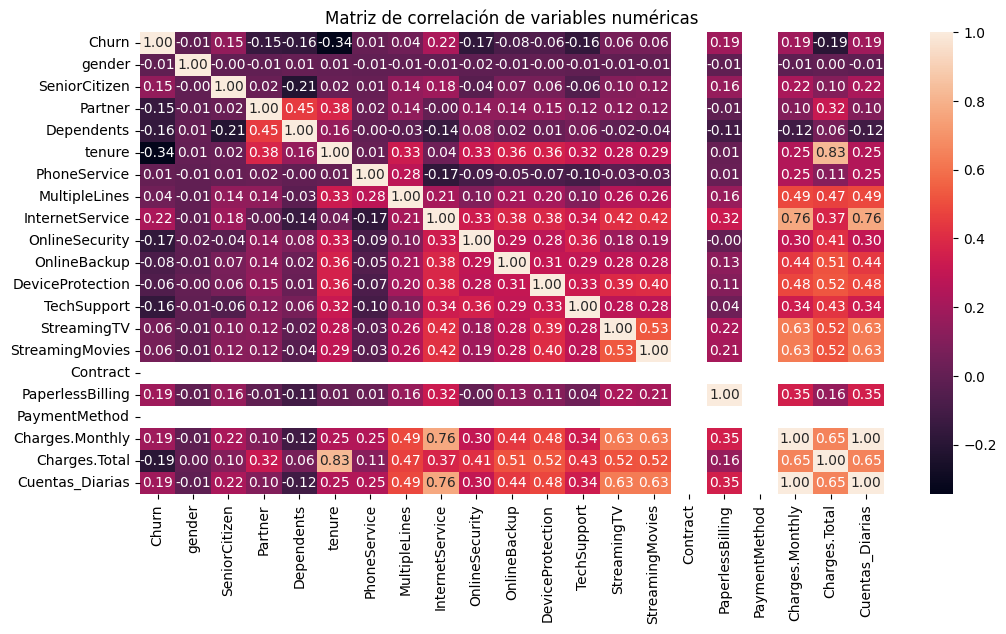

In [90]:
# crear grafico de matriz de correlacion
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(datos.corr(numeric_only=True),annot=True,fmt=".2f")

plt.title("Matriz de correlación de variables numéricas")
fmt=".2f"
plt.show()

## Análisis Dirigido

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

- Tiempo de contrato × Cancelación
- Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

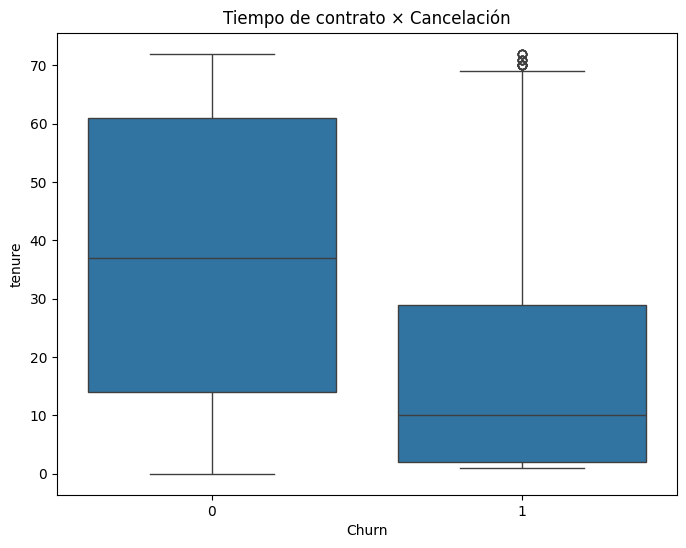

In [91]:
# crear gráficos como boxplots Tiempo de contrato × Cancelación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='tenure',data=datos) #tenure(meses de contrato del cliente)
plt.title("Tiempo de contrato × Cancelación") # Cancelación (0 = No, 1 = Sí)
plt.show()

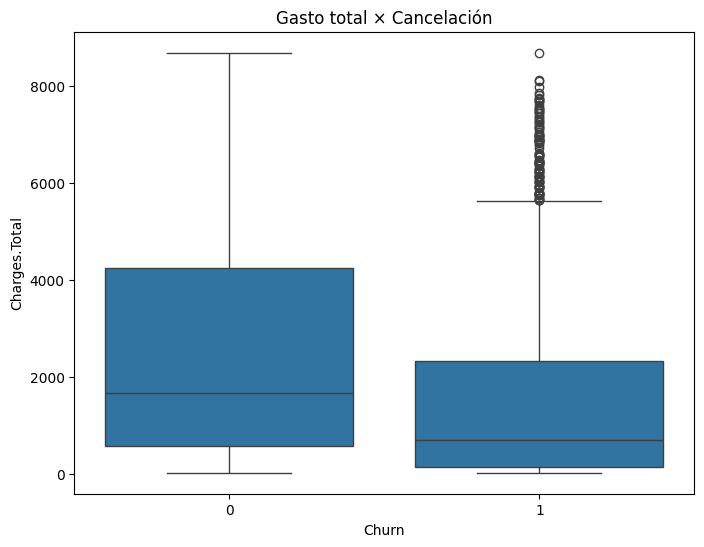

In [92]:
# crear grafico scatter plots Gasto total × Cancelación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Churn',y='Charges.Total',data=datos)
plt.title("Gasto total × Cancelación")
plt.show()

# 🤖 Modelado Predictivo



## Separación de Datos

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [93]:
# definir variables independiente(predictoria)
X = datos_codificados.drop('Churn', axis=1)

# variable de respuesta(objetivo)
y = datos_codificados['Churn']

## Creación de Modelos

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

* Un modelo puede requerir normalización, como Regresión Logística o KNN.

* El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

**Justificación:**

- **Regresión Logística / KNN:** Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

- **Árbol de Decisión / Random Forest:** Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

### Modelo - Regresión Logística

In [94]:
# crear modelo de Regresión Logística
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Handle missing values by dropping rows with NaNs
datos_codificados_cleaned = datos_codificados.dropna()

# definir variables independiente(predictoria)
X = datos_codificados_cleaned.drop('Churn', axis=1)

# variable de respuesta(objetivo)
y = datos_codificados_cleaned['Churn']

# crear modelo
modelo_regresion_logistica = LogisticRegression(max_iter=1000) # Increased max_iter for convergence

# datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# entrenar el modelo
modelo_regresion_logistica.fit(X_train, y_train)

# conocer puntaje
print("Puntaje de entrenamiento:", modelo_regresion_logistica.score(X_train, y_train))
print("Puntaje de prueba:", modelo_regresion_logistica.score(X_test, y_test))



Puntaje de entrenamiento: 0.7977948415042331
Puntaje de prueba: 0.8001837390904915


## Evaluación de los Modelos

Evalúa cada modelo utilizando las siguientes métricas:

- Exactitud (Acurácia)
- Precisión
- Recall
- F1-score
- Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

- ¿Cuál modelo tuvo el mejor desempeño?
- ¿Algún modelo presentó **overfitting o underfitting**? Si es así, considera las posibles causas y ajustes:

**Overfitting:** Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

**Underfitting:** Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [95]:
# evaluar modelo usando metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# crear variable
y_pred = modelo_regresion_logistica.predict(X_test)

# crear funcion
def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    metricas = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': conf_matrix
    }
    return metricas

In [96]:
# imprimir resultados
resultados_modelo_regresion_logistica = evaluate_model(y_test, y_pred)
#resultados_modelo_regresion_logistica
print("Métricas del modelo de Regresión Logística:", resultados_modelo_regresion_logistica)

Métricas del modelo de Regresión Logística: {'Accuracy': 0.8001837390904915, 'Precision': 0.6359223300970874, 'Recall': 0.4789762340036563, 'F1 Score': 0.5464025026068822, 'Confusion Matrix': array([[1480,  150],
       [ 285,  262]])}


### Moldelo Bosque aleatorio

In [97]:
# Bosque aleatorio
from sklearn.ensemble import RandomForestClassifier

# crear modelo
modelo_bosque_aleatorio = RandomForestClassifier(random_state=42)

# entrenar el modelo
modelo_bosque_aleatorio.fit(X_train, y_train)
y_pred = modelo_bosque_aleatorio.predict(X_test)

# imprimir resultados
resultados_modelo_bosque_aleatorio = evaluate_model(y_test, y_pred)
resultados_modelo_bosque_aleatorio





{'Accuracy': 0.7873220027560863,
 'Precision': 0.6019417475728155,
 'Recall': 0.453382084095064,
 'F1 Score': 0.5172054223149114,
 'Confusion Matrix': array([[1466,  164],
        [ 299,  248]])}

In [99]:
# graficar matriz


# 📋 Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

- **Regresión Logística:** Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

- **KNN (K-Nearest Neighbors):** Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

- **Random Forest:** Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

- **SVM (Support Vector Machine):** En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

- **Otros Modelos:** Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

## Conclusión

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.